# Cross-Validation

**INDE 577 / CMOR 438 — Rice University**  \
**Instructor:** Randy R. Davila, PhD

---

## Overview

**Cross-validation** is a resampling technique for estimating how well a model generalises  
to unseen data without requiring a separate hold-out test set.

### Why cross-validation?
- A single train/test split gives a high-variance estimate of model performance.
- CV uses the data more efficiently by rotating which portion is held out.
- It enables **model selection** (hyperparameter tuning) without peeking at the test set.

### K-Fold Cross-Validation

The dataset is partitioned into *k* roughly equal **folds**.  
The model is trained on *k − 1* folds and evaluated on the remaining fold, repeated *k* times.

$$CV_k = \frac{1}{k}\sum_{i=1}^{k} \text{score}(f_i,\ D_i^{\text{val}})$$

**Stratified K-Fold** preserves the class proportion in each fold, which is essential  
for imbalanced classification problems.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_breast_cancer, make_regression
from sklearn.preprocessing import StandardScaler

from rice_ml.processing.cross_validation import KFold, StratifiedKFold, cross_val_score
from rice_ml.supervised_learning.linear_regression import LinearRegression, RidgeRegression
from rice_ml.supervised_learning.logistic_regression import LogisticRegression

np.random.seed(42)
print("Imports OK")
print(f"KFold: {KFold}, StratifiedKFold: {StratifiedKFold}")


Imports OK
KFold: <class 'rice_ml.processing.cross_validation.KFold'>, StratifiedKFold: <class 'rice_ml.processing.cross_validation.StratifiedKFold'>


## 1. Visualising K-Fold Splits

Each row represents one fold; blue cells are training samples, orange are validation.


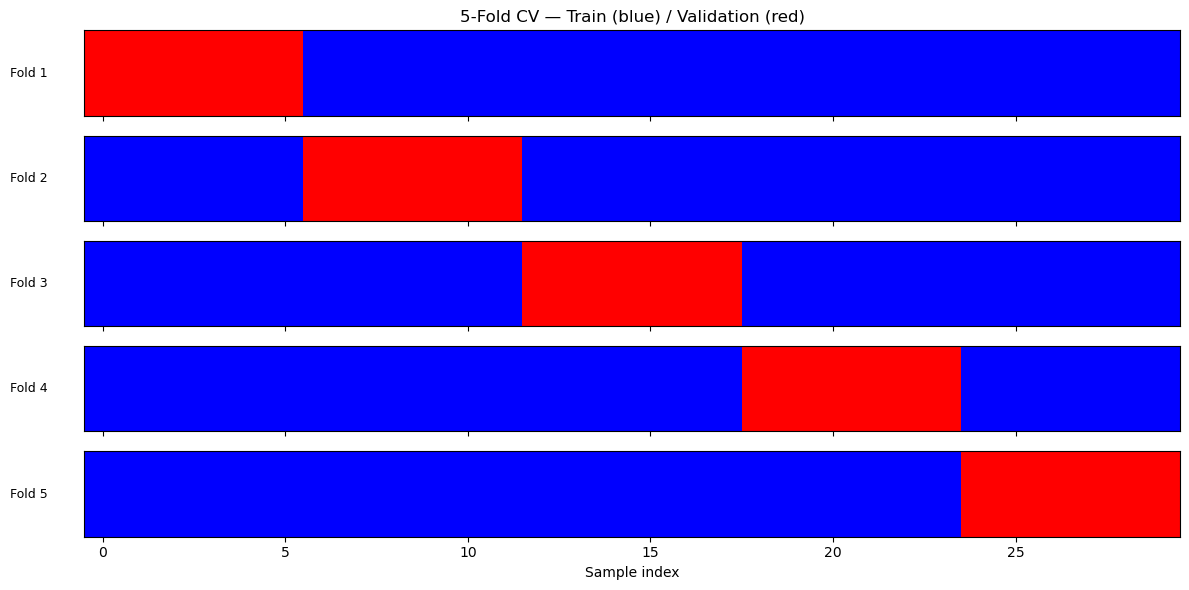

In [2]:
n_samples = 30
X_demo = np.arange(n_samples).reshape(-1, 1)
y_demo = np.zeros(n_samples)

fig, axes = plt.subplots(5, 1, figsize=(12, 6), sharex=True)
kf = KFold(n_splits=5, shuffle=False)
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_demo, y_demo)):
    ax = axes[fold_idx]
    bar = np.zeros(n_samples)
    bar[val_idx] = 1
    ax.imshow(bar.reshape(1, -1), aspect='auto', cmap='bwr', vmin=0, vmax=1)
    ax.set_yticks([])
    ax.set_ylabel(f'Fold {fold_idx+1}', rotation=0, labelpad=40, va='center', fontsize=9)
    if fold_idx == 4:
        ax.set_xlabel('Sample index')

axes[0].set_title('5-Fold CV — Train (blue) / Validation (red)', fontsize=12)
plt.tight_layout()
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/cv_fold_splits.png', dpi=110, bbox_inches='tight')
plt.show()


## 2. KFold Mechanics

Each sample appears in exactly **one** validation fold across all splits.


In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=7)
X = np.random.randn(20, 2)
y = np.zeros(20)

print(f"{'Fold':>5}  {'Train indices':50}  {'Val indices'}")
print('-'*80)
for i, (tr, va) in enumerate(kf.split(X, y)):
    print(f"  {i+1}    {str(sorted(tr)):50}  {sorted(va)}")
print(f"\nTotal splits: {kf.n_splits}")
print(f"Validation sizes: {[len(va) for _, va in kf.split(X,y)]}")


 Fold  Train indices                                       Val indices
--------------------------------------------------------------------------------
  1    [np.int64(0), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(19)]  [np.int64(1), np.int64(2), np.int64(5), np.int64(17)]
  2    [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19)]  [np.int64(0), np.int64(6), np.int64(11), np.int64(18)]
  3    [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(12), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]  [np.int64(10), np.int64(13), np.int64(14), np.int64(19)]
  4    [

## 3. Stratified K-Fold

For classification, `StratifiedKFold` ensures each fold contains approximately  
the same proportion of each class as the full dataset.


In [4]:
from collections import Counter

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

print("Class proportions per fold (Iris, 3 classes):")
print(f"{'Fold':>5}  {'Class 0':>8}  {'Class 1':>8}  {'Class 2':>8}  {'Total':>7}")
print('-'*50)
for i, (tr, va) in enumerate(skf.split(X_iris, y_iris)):
    cnt = Counter(y_iris[va])
    print(f"  {i+1}    {cnt[0]:>8}  {cnt[1]:>8}  {cnt[2]:>8}  {len(va):>7}")

print("\nOverall class distribution:", Counter(y_iris))


Class proportions per fold (Iris, 3 classes):
 Fold   Class 0   Class 1   Class 2    Total
--------------------------------------------------
  1          10        10        10       30
  2          10        10        10       30
  3          10        10        10       30
  4          10        10        10       30
  5          10        10        10       30

Overall class distribution: Counter({np.int64(0): 50, np.int64(1): 50, np.int64(2): 50})


## 4. Cross-Validation Scores — Classification

We evaluate `LogisticRegression` on the Iris and Breast Cancer datasets  
using `cross_val_score` with accuracy scoring.


In [5]:
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target

bc = load_breast_cancer()
X_bc = StandardScaler().fit_transform(bc.data)
y_bc = bc.target

lr_clf = LogisticRegression(learning_rate=0.1, n_iterations=500)

scores_iris = cross_val_score(lr_clf, X_iris, y_iris, cv=5, scoring='accuracy')
scores_bc   = cross_val_score(lr_clf, X_bc,   y_bc,   cv=5, scoring='accuracy')

print("Logistic Regression — 5-Fold CV Accuracy")
print(f"  Iris          : {scores_iris}")
print(f"  Iris mean±std : {scores_iris.mean():.4f} ± {scores_iris.std():.4f}")
print()
print(f"  Breast Cancer : {scores_bc}")
print(f"  BC mean±std   : {scores_bc.mean():.4f} ± {scores_bc.std():.4f}")


Logistic Regression — 5-Fold CV Accuracy
  Iris          : [1.         0.96666667 1.         0.26666667 0.        ]
  Iris mean±std : 0.6467 ± 0.4277

  Breast Cancer : [0.96491228 0.96491228 0.98245614 0.98245614 0.99115044]
  BC mean±std   : 0.9772 ± 0.0105


## 5. Cross-Validation Scores — Regression

We compare ordinary `LinearRegression` vs `RidgeRegression` using R² and  
negative-RMSE scoring on a synthetic dataset.


In [6]:
X_reg, y_reg = make_regression(n_samples=200, n_features=10, noise=10, random_state=0)
X_reg = StandardScaler().fit_transform(X_reg)

ols   = LinearRegression(method='gradient_descent', n_iterations=1000, learning_rate=0.01)
ridge = RidgeRegression(alpha=1.0)

for name, model in [('OLS  (GD)', ols), ('Ridge', ridge)]:
    r2   = cross_val_score(model, X_reg, y_reg, cv=5, scoring='r2')
    rmse = cross_val_score(model, X_reg, y_reg, cv=5, scoring='neg_rmse')
    print(f"{name}  R²={r2.mean():.4f}±{r2.std():.4f}   "
          f"RMSE={(-rmse).mean():.4f}±{(-rmse).std():.4f}")


OLS  (GD)  R²=0.9940±0.0006   RMSE=10.2702±0.7011
Ridge  R²=0.9940±0.0007   RMSE=10.2673±0.7386


## 6. Visualising Score Distributions

A box plot shows variability across folds — high variance may indicate  
the model is sensitive to which samples end up in training vs validation.


/var/folders/bk/hd75sxwn059bvv7ywtmgtvp00000gn/T/ipykernel_77090/281937134.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(list(datasets.values()), labels=list(datasets.keys()), patch_artist=True,
/var/folders/bk/hd75sxwn059bvv7ywtmgtvp00000gn/T/ipykernel_77090/281937134.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([ols_r2, ridge_r2], labels=['OLS (GD)', 'Ridge'], patch_artist=True,


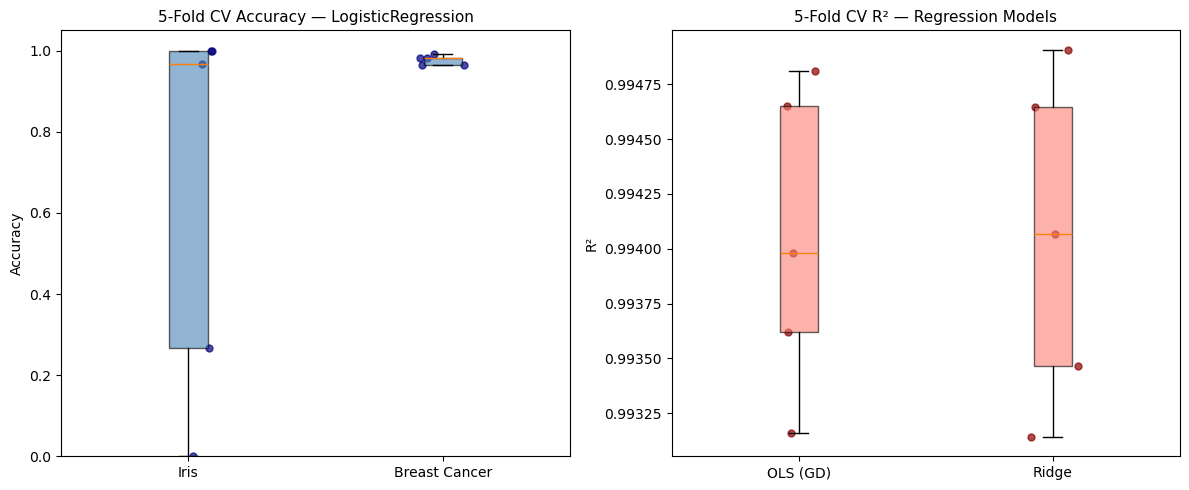

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
datasets = {'Iris': scores_iris, 'Breast Cancer': scores_bc}
ax = axes[0]
ax.boxplot(list(datasets.values()), labels=list(datasets.keys()), patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_title('5-Fold CV Accuracy — LogisticRegression', fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
for i, (name, scores) in enumerate(datasets.items(), 1):
    for s in scores:
        ax.scatter(i + np.random.uniform(-0.1, 0.1), s, color='navy', alpha=0.7, s=25)

# R² comparison
ols_r2   = cross_val_score(LinearRegression(method='gradient_descent',
                             n_iterations=1000, learning_rate=0.01),
                           X_reg, y_reg, cv=5, scoring='r2')
ridge_r2 = cross_val_score(RidgeRegression(alpha=1.0), X_reg, y_reg, cv=5, scoring='r2')
ax2 = axes[1]
ax2.boxplot([ols_r2, ridge_r2], labels=['OLS (GD)', 'Ridge'], patch_artist=True,
            boxprops=dict(facecolor='salmon', alpha=0.6))
ax2.set_title('5-Fold CV R² — Regression Models', fontsize=11)
ax2.set_ylabel('R²')
for i, scores in enumerate([ols_r2, ridge_r2], 1):
    for s in scores:
        ax2.scatter(i + np.random.uniform(-0.1, 0.1), s, color='darkred', alpha=0.7, s=25)

plt.tight_layout()
plt.savefig('figures/cv_scores.png', dpi=110, bbox_inches='tight')
plt.show()


## 7. Learning Curves via Cross-Validation

A **learning curve** plots train and CV validation score as a function of training set size.  
It reveals whether a model suffers from **high bias** or **high variance**.


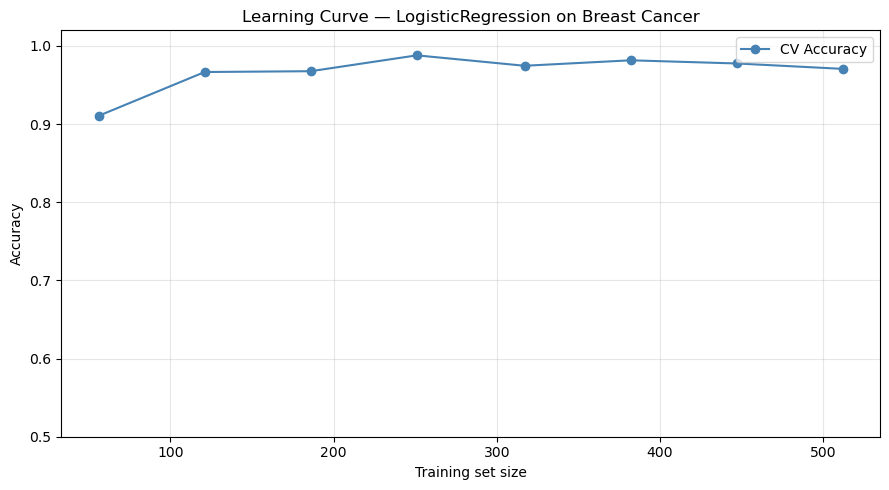

In [8]:
from rice_ml.supervised_learning.logistic_regression import LogisticRegression as LR

X_lc = StandardScaler().fit_transform(bc.data)
y_lc = bc.target

train_sizes = np.linspace(0.1, 0.9, 8)
train_means, val_means = [], []

for frac in train_sizes:
    n = max(int(frac * len(y_lc)), 2 * len(np.unique(y_lc)))
    idx = np.random.choice(len(y_lc), n, replace=False)
    X_sub, y_sub = X_lc[idx], y_lc[idx]
    val_scores = cross_val_score(LR(learning_rate=0.1, n_iterations=500),
                                 X_sub, y_sub, cv=5, scoring='accuracy')
    val_means.append(val_scores.mean())

fig, ax = plt.subplots(figsize=(9, 5))
ns = [max(int(f * len(y_lc)), 10) for f in train_sizes]
ax.plot(ns, val_means, 'o-', color='steelblue', label='CV Accuracy')
ax.set_xlabel('Training set size')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve — LogisticRegression on Breast Cancer', fontsize=12)
ax.legend()
ax.set_ylim(0.5, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/cv_learning_curve.png', dpi=110, bbox_inches='tight')
plt.show()


## Summary

| Technique | Folds | Key use |
|---|---|---|
| `KFold` | k equal parts | Regression or balanced classification |
| `StratifiedKFold` | k class-proportional parts | Imbalanced classification |
| `cross_val_score` | Wraps any estimator | Quick generalisation estimate |

### Scoring options in `rice_ml`

| String | Metric |
|---|---|
| `'accuracy'` | Fraction of correct predictions |
| `'r2'` | Coefficient of determination |
| `'neg_mse'` | −MSE (higher is better) |
| `'neg_rmse'` | −RMSE (higher is better) |

## Model Limitations

- **Standard K-Fold assumes i.i.d. data** — for time-series data, use `TimeSeriesSplit` (future data must not leak into training).
- **k must be ≤ n** — with very small datasets, leave-one-out CV (k = n) is more reliable but computationally expensive.
- **Stratification requires ≥ k samples per class** — rare classes with fewer samples than folds will cause errors.
- **Cross-validation estimates generalisation error but does not prevent overfitting** — if you tune hyperparameters on CV score, a separate held-out test set is still needed for an unbiased final evaluation.
- **Computational cost** — training k models is k× more expensive than a single train/test split, which matters for slow models.
